In [3]:
"""
Written by: Tommy Banker (thomas_banker@berkeley.edu)
"""

import os
import json
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
from utils import *




matplotlib.rcParams.update({# Use mathtext, not LaTeX
                            'text.usetex': False,
                            # Use the Computer modern font
                            'font.family': 'serif',
                            'font.serif': 'cmr10',
                            'mathtext.fontset': 'cm',
                            # Use ASCII minus
                            'axes.unicode_minus': False,
                            'figure.dpi' : 300,

                            })

font = {'weight' : 'bold',
        'size'   : 34}
plt.rc('font', **font)





In [4]:
methods = ['cep', ]
best_list = {'cep': 11.086613 }
best = best_list['cep']
seeds = [0,1,2,3,4,]


In [6]:
sample_configs = [ r'./config/cep/CEP_SAAS_0.json',]


names = ['SAAS q=1','SAAS q=4','SAAS q=8', ]
names2 = ['MolDAIS q=1','MolDAIS q=4',"MolDAIS q=8"]

Res_dict_raw  = {'SAAS q=1':[], 'SAAS q=4':[],'SAAS q=8':[]}        
Res_dict_stat = {'SAAS q=1':[], 'SAAS q=4':[],'SAAS q=8':[]}               
Smi_dict_stat = {'SAAS q=1':[], 'SAAS q=4':[],'SAAS q=8':[]}                  


end = -1

for i100,sample_config in enumerate(sample_configs):        
    with open(sample_config) as f:
        exp_config = json.load(f)
    ########    
    y_variable = exp_config['common']['y_variable']
    max_min = exp_config['common']['max_min']
    init_budget = exp_config['common']['init_budget']
    total_budget = exp_config['common']['total_budget'] 
    bo_iters = np.arange(1, total_budget - init_budget + 1)
    ########
    all_results = np.zeros((len(methods), len(seeds), total_budget))
    smi_results = []
    sorted_results = np.zeros((len(methods), len(seeds), total_budget - init_budget + 1))
    conv_results = np.zeros((len(methods), (total_budget - init_budget + 1), 2))
    ########
    for i, method in enumerate(methods):
        for j, seed in enumerate(seeds):
            exp_config['exp_name'] = method #+ '_' + str(seed) 
            exp_config['seed'] = seed
            path = os.path.join('../results/', 'cep',)
                
            filename = get_filename(bo_iters[-1], exp_config).replace('_q_1', '')
            print(filename)
            result = torch.load(os.path.join(path, filename + '.pkl'))
            all_results[i,j,:] = result['y_train'].squeeze()
            smi_results.append( result['smiles_train'])
    ########
    sorted_results[:,:,0] = np.max(all_results[:,:,:init_budget], axis=2)
    for i, method in enumerate(methods):
        for j, seed in enumerate(seeds):
            for sample in np.arange(total_budget - init_budget + end):
                if all_results[i,j,(init_budget + sample)] > sorted_results[i,j,sample]:
                    sorted_results[i,j,(sample + 1)] = all_results[i,j,(init_budget + sample)]
                else:
                    sorted_results[i,j,(sample + 1)] = sorted_results[i,j,(sample)]
    ########
    for i, method in enumerate(methods):
        for sample in np.arange(total_budget - init_budget + 1+ end):
            conv_results[i,sample,0] = np.mean(sorted_results[i,:,sample])
            conv_results[i,sample,1] = np.std(sorted_results[i,:,sample])
    ########
    sample_numbers = np.arange(total_budget - init_budget + 1)
    if max_min == 'max':
        conv_results[:,:,0] = (conv_results[:,:,0]- best*0  )#*-1  #- max_min_vars[y_variable]['max']) * -1
    else:   # convention appears strange bc results as stored are already the
            # negative of the true values to perform minimization experiments
        conv_results[:,:,0] = (conv_results[:,:,0] - -1 * max_min_vars[y_variable]['min']) * -1
    
    
    Res_dict_raw[names[0]] = sorted_results
    Res_dict_stat[names[0]] = conv_results    
    Smi_dict_stat[names[0]] = smi_results
    
    

    
    
    
Q = [4,8,]    
sample_configs = [ r'./config/cep_q/CEP_SAAS_0.json',]



end = -1

for i100,sample_config in enumerate(sample_configs):        
    with open(sample_config) as f:
        exp_config = json.load(f)
    ########    
    for k,q in enumerate(Q):
        exp_config['bo']['acq_fun_params']['q'] = q
        y_variable = exp_config['common']['y_variable']
        max_min = exp_config['common']['max_min']
        init_budget = exp_config['common']['init_budget']
        total_budget = exp_config['common']['total_budget'] 
        bo_iters = np.arange(1, int((total_budget - init_budget)+1))
        ########
        all_results = np.zeros((len(methods), len(seeds), total_budget))
        smi_results = []
        sorted_results = np.zeros((len(methods), len(seeds), total_budget - init_budget + 1))
        conv_results = np.zeros((len(methods), (total_budget - init_budget + 1), 2))
        ########
        for i, method in enumerate(methods):
            for j, seed in enumerate(seeds):
                exp_config['exp_name'] = method #+ '_' + str(seed) 
                exp_config['seed'] = seed
                path = os.path.join('../results/', 'cep_q/cep',)

                filename = get_filename(bo_iters[-1], exp_config).replace('iter_90', 'iter_'+str(int((total_budget - init_budget)/q)))
                print(os.path.join(path, filename + '.pkl'))
                result = torch.load(os.path.join(path, filename + '.pkl'))
                all_results[i,j,:] = result['y_train'].squeeze()[:total_budget]
                smi_results.append( result['smiles_train'])
        ########
        sorted_results[:,:,0] = np.max(all_results[:,:,:init_budget], axis=2)
        for i, method in enumerate(methods):
            for j, seed in enumerate(seeds):
                for sample in np.arange(total_budget - init_budget + end):
                    if all_results[i,j,(init_budget + sample)] > sorted_results[i,j,sample]:
                        sorted_results[i,j,(sample + 1)] = all_results[i,j,(init_budget + sample)]
                    else:
                        sorted_results[i,j,(sample + 1)] = sorted_results[i,j,(sample)]
        ########
        for i, method in enumerate(methods):
            for sample in np.arange(total_budget - init_budget + 1+ end):
                conv_results[i,sample,0] = np.mean(sorted_results[i,:,sample])
                conv_results[i,sample,1] = np.std(sorted_results[i,:,sample])
        ########
        sample_numbers = np.arange(total_budget - init_budget + 1)
        if max_min == 'max':
            conv_results[:,:,0] = (conv_results[:,:,0]- best*0  )#*-1  #- max_min_vars[y_variable]['max']) * -1
        else:   # convention appears strange bc results as stored are already the
                # negative of the true values to perform minimization experiments
            conv_results[:,:,0] = (conv_results[:,:,0] - -1 * max_min_vars[y_variable]['min']) * -1
    
    
        Res_dict_raw[names[k+1]] = sorted_results
        Res_dict_stat[names[k+1]] = conv_results    
        Smi_dict_stat[names[k+1]] = smi_results
    
    
    

cep_max_activity_SAASGP_seed_0_bo-iter_90_10_to_100_samples_EI_None_None
cep_max_activity_SAASGP_seed_1_bo-iter_90_10_to_100_samples_EI_None_None
cep_max_activity_SAASGP_seed_2_bo-iter_90_10_to_100_samples_EI_None_None
cep_max_activity_SAASGP_seed_3_bo-iter_90_10_to_100_samples_EI_None_None
cep_max_activity_SAASGP_seed_4_bo-iter_90_10_to_100_samples_EI_None_None
../results/cep_q/cep/cep_max_activity_SAASGP_q_4_seed_0_bo-iter_22_10_to_100_samples_qEI_None_None.pkl
../results/cep_q/cep/cep_max_activity_SAASGP_q_4_seed_1_bo-iter_22_10_to_100_samples_qEI_None_None.pkl
../results/cep_q/cep/cep_max_activity_SAASGP_q_4_seed_2_bo-iter_22_10_to_100_samples_qEI_None_None.pkl
../results/cep_q/cep/cep_max_activity_SAASGP_q_4_seed_3_bo-iter_22_10_to_100_samples_qEI_None_None.pkl
../results/cep_q/cep/cep_max_activity_SAASGP_q_4_seed_4_bo-iter_22_10_to_100_samples_qEI_None_None.pkl
../results/cep_q/cep/cep_max_activity_SAASGP_q_8_seed_0_bo-iter_11_10_to_100_samples_qEI_None_None.pkl
../results/cep_q/

/tmp/ipykernel_917392/595711308.py:7: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.plot(sample_numbers[:end], conv_results[0,:end,0], style, linewidth=3, label=names2[i], c=colors[i])
/tmp/ipykernel_917392/595711308.py:25: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.plot(sample_numbers[:end], conv_results[0,:end,0], style, linewidth=3, label=names2[i], c=colors[i])


"    \n#sorted_results\nfig = plt.figure(figsize=(12,9))\nfor i, method in enumerate(names):\n    \n    style = '-'\n    sorted_results = Res_dict_raw[method]\n    plt.plot(sample_numbers, -1*sorted_results.squeeze(0).T+best, style, linewidth=3, label=method, c=colors[i])\n    #plt.fill_between(sample_numbers, conv_results[i,:,0]-(1.95*conv_results[i,:,1]/(len(seeds)**0.5)), conv_results[i,:,0]+(1.95*conv_results[i,:,1]/(len(seeds)**0.5)), alpha=0.1, color=colors[i])\n    #plt.title('Convergence Results Across ' + str(len(seeds)) + ' Runs with ' + str(init_budget) + ' Initial Random Samples')\nplt.xlabel('Iterations')\nplt.ylabel('Regret' )\n#plt.yscale('log')\nplt.ylim(0,1)    \nplt.xlim(0,90+end)   "

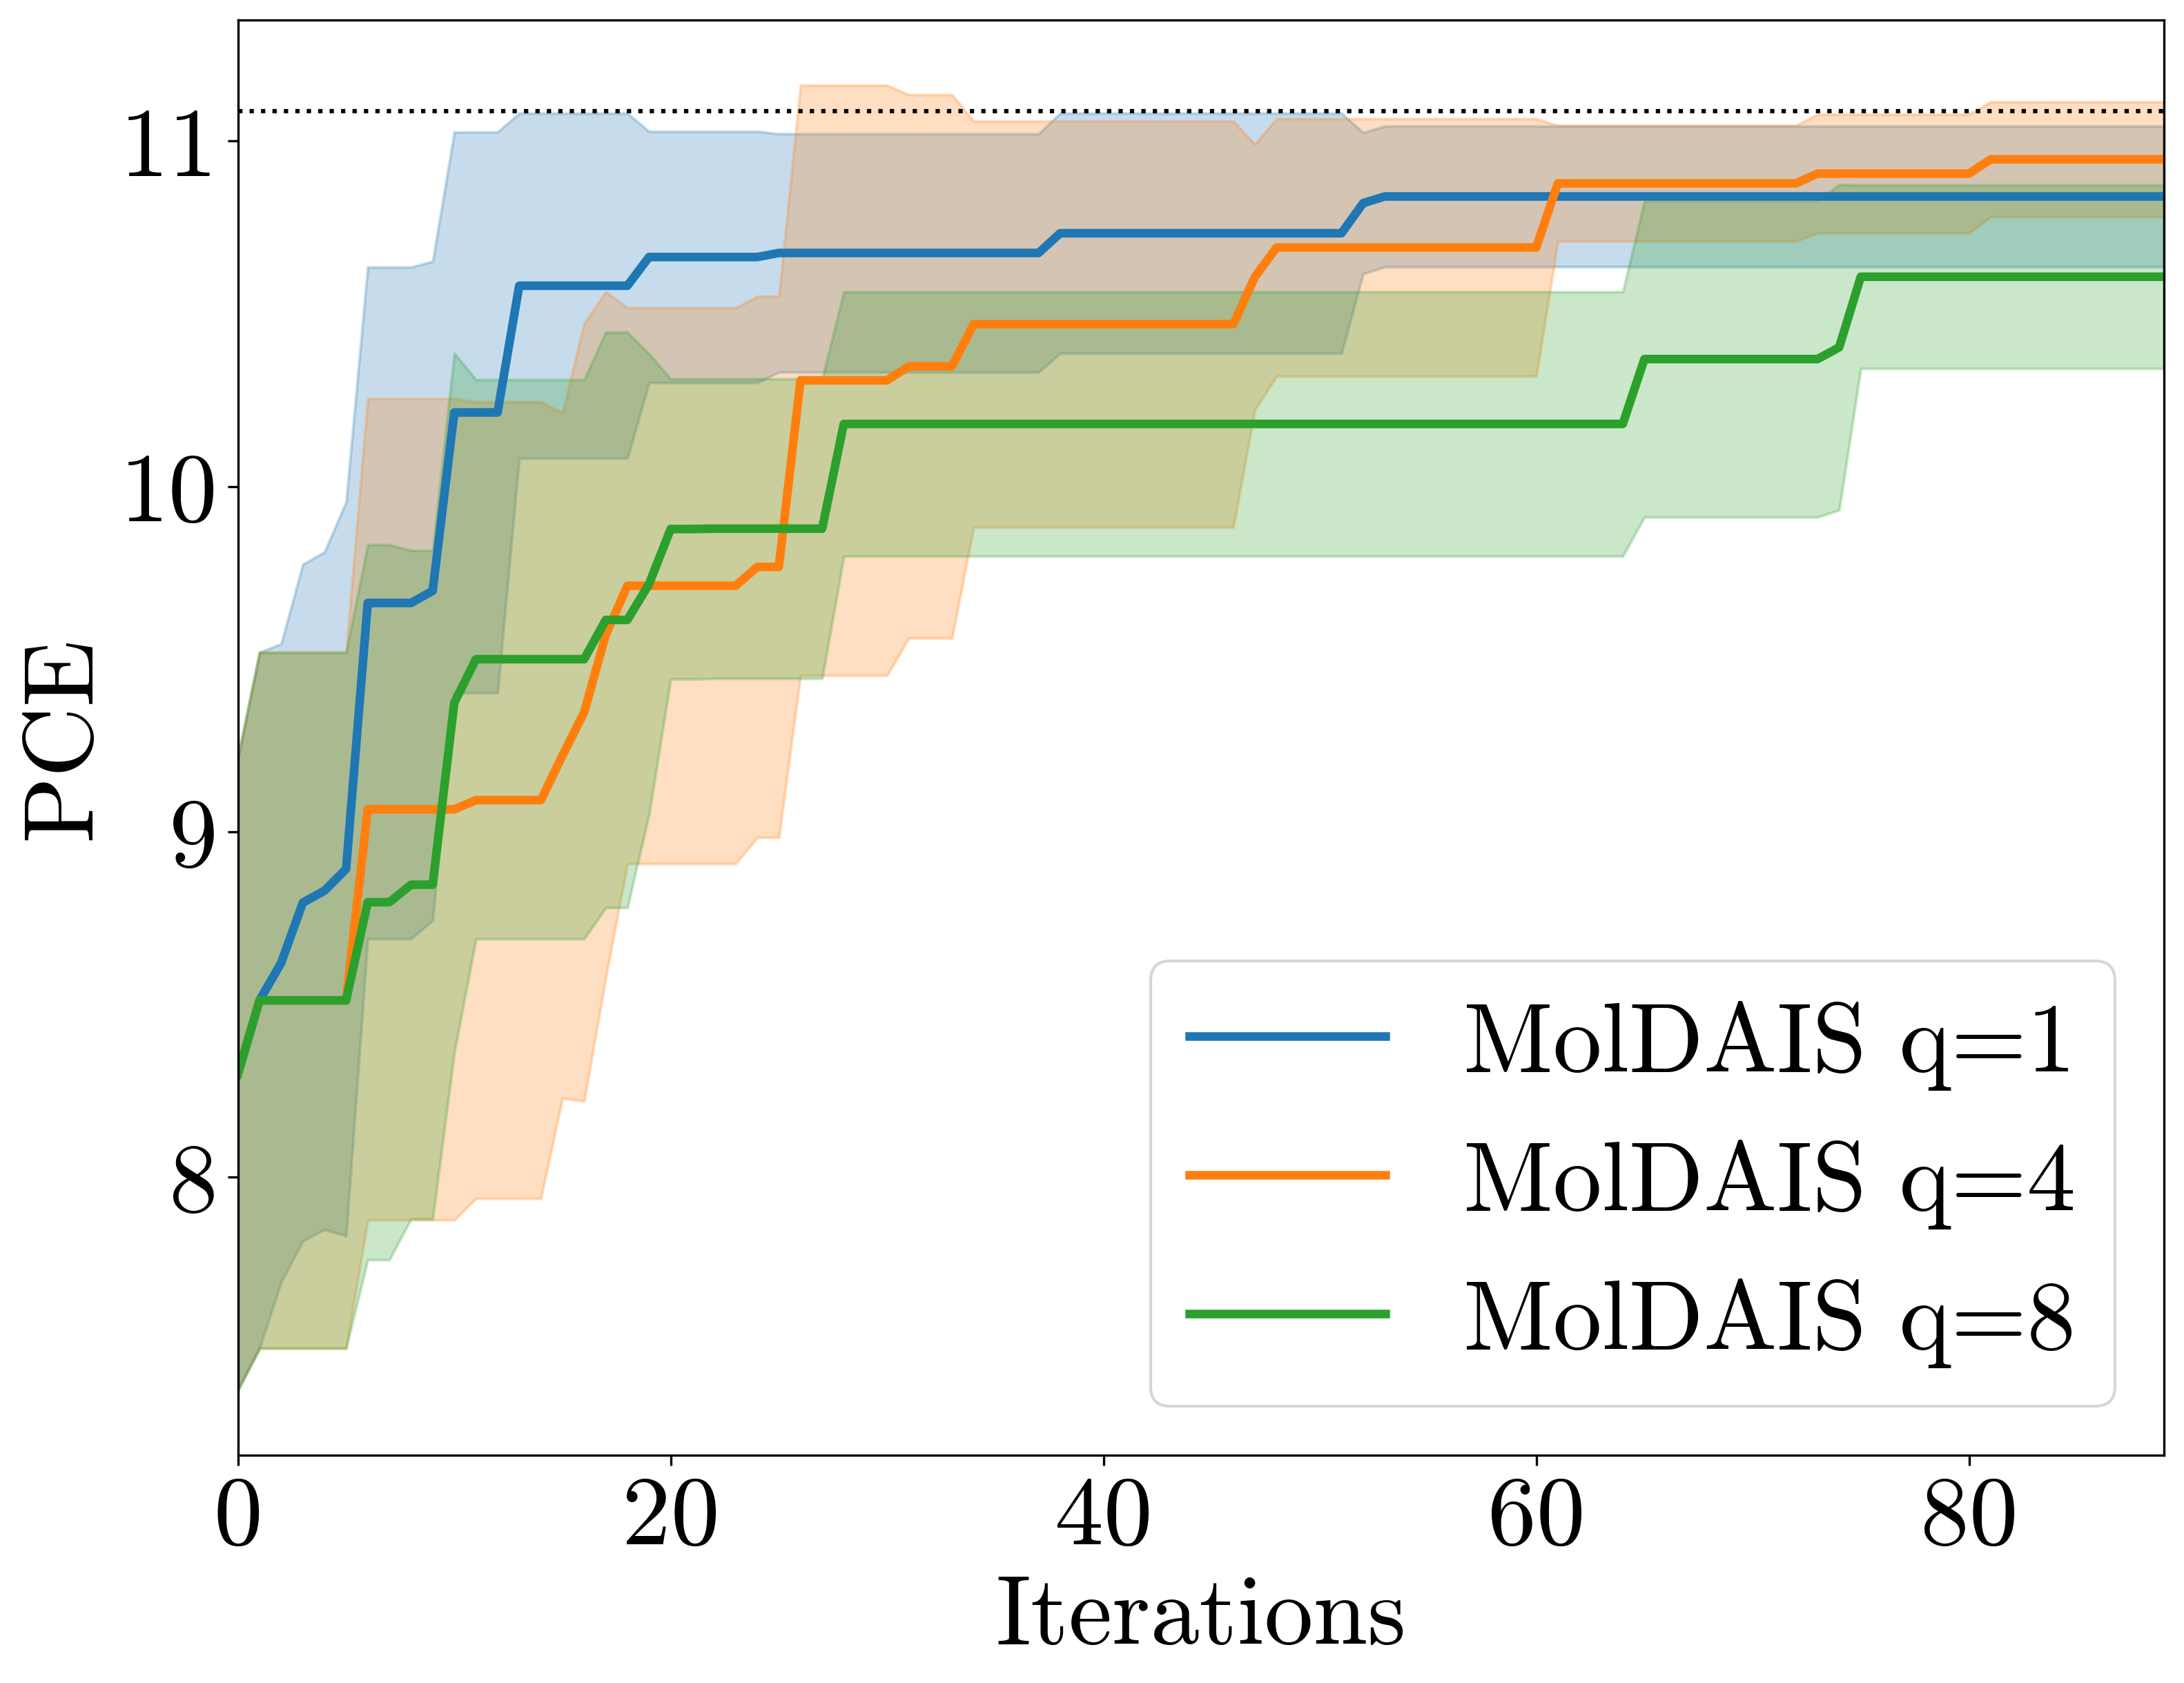

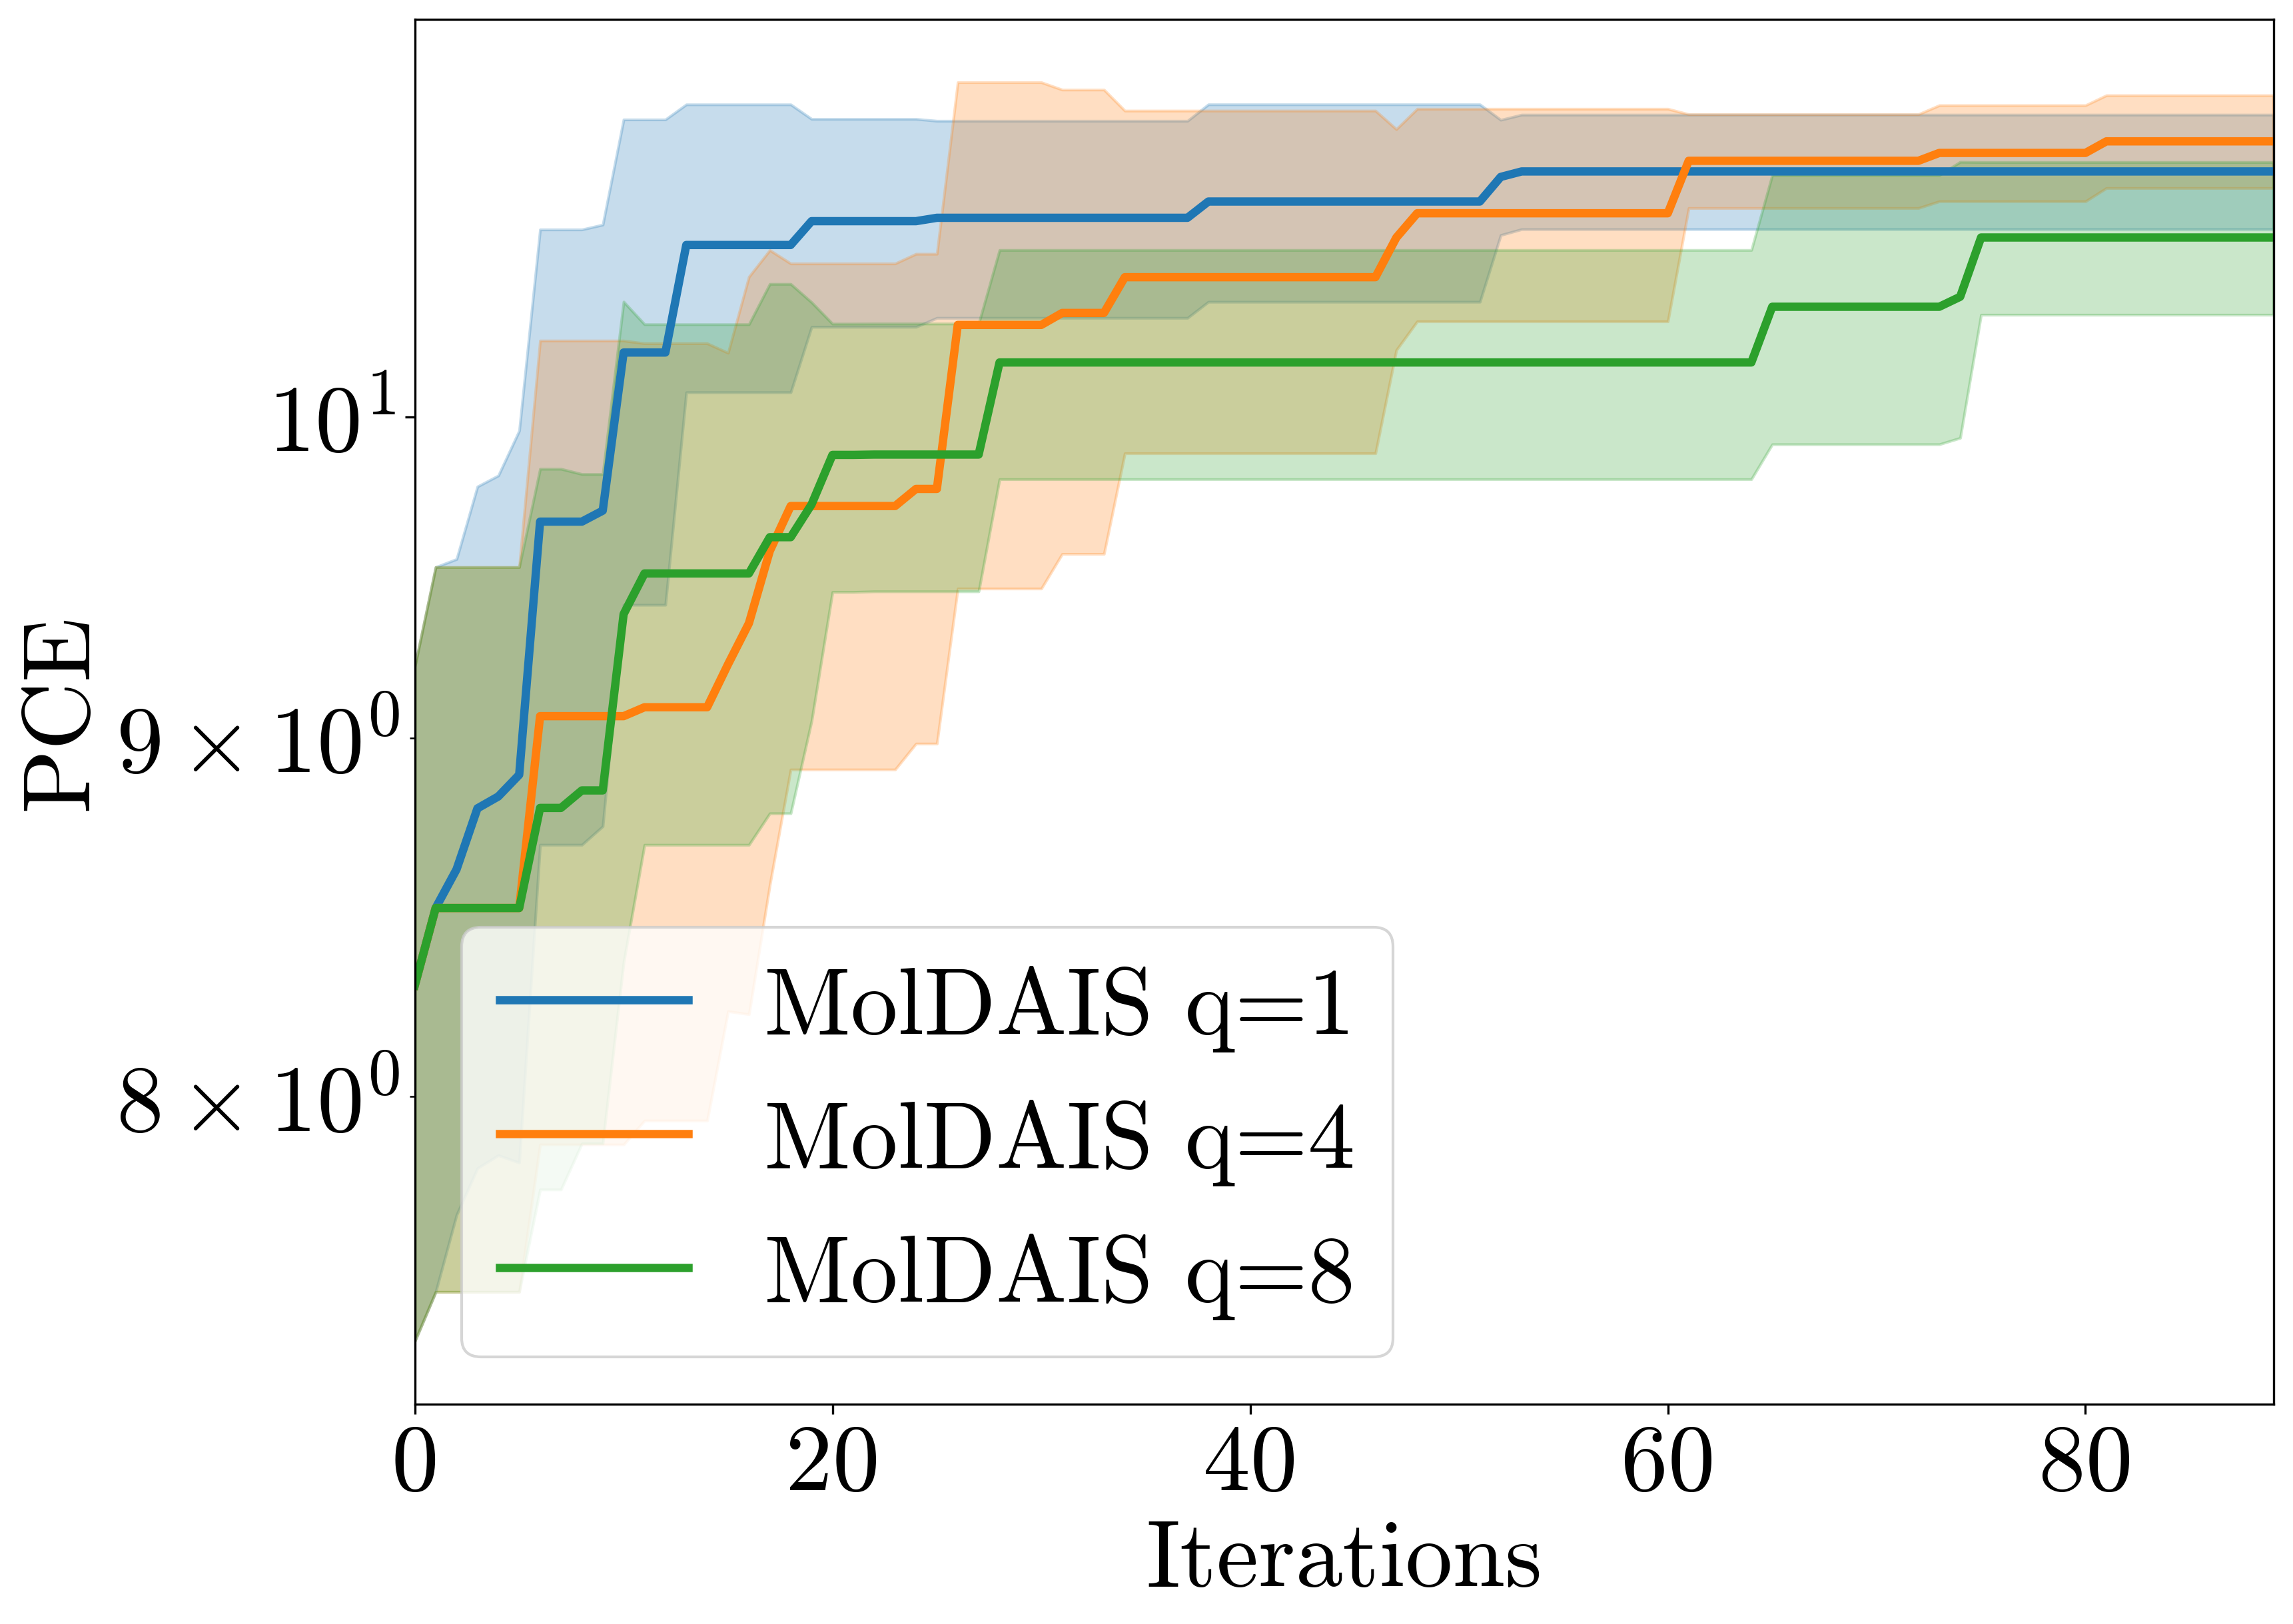

In [7]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#01015c','#0302FC', ] 

fig = plt.figure(figsize=(12,9))
for i, method in enumerate(names):
    style = '-'
    conv_results = Res_dict_stat[method]
    plt.plot(sample_numbers[:end], conv_results[0,:end,0], style, linewidth=3, label=names2[i], c=colors[i])
    plt.fill_between(sample_numbers[:end], conv_results[0,:end,0]-(1.95*conv_results[0,:end,1]/(len(seeds)**0.5)), conv_results[0,:end,0]+(1.95*conv_results[0,:end,1]/(len(seeds)**0.5)), alpha=0.25, color=colors[i])
plt.plot([0,90+end], [11.086613,11.086613], 'k:')
plt.legend(loc=0)
#plt.title('Convergence Results Across ' + str(len(seeds)) + ' Runs with ' + str(init_budget) + ' Initial Random Samples')
plt.xlabel('Iterations')
plt.ylabel('PCE' )
#plt.yscale('log')
plt.xlim(0,90+end)    
#plt.ylim(0,3.5)#.75) 
plt.savefig('./figs/cep/Convergence_q.png')
    
    

fig = plt.figure(figsize=(12,9))
for i, method in enumerate(names):
    style = '-'
    conv_results = Res_dict_stat[method]
    plt.plot(sample_numbers[:end], conv_results[0,:end,0], style, linewidth=3, label=names2[i], c=colors[i])
    plt.fill_between(sample_numbers[:end], conv_results[0,:end,0]-(1.95*conv_results[0,:end,1]/(len(seeds)**0.5)), conv_results[0,:end,0]+(1.95*conv_results[0,:end,1]/(len(seeds)**0.5)), alpha=0.25, color=colors[i])
plt.legend(loc=0)
#plt.title('Convergence Results Across ' + str(len(seeds)) + ' Runs with ' + str(init_budget) + ' Initial Random Samples')
plt.xlabel('Iterations')
plt.ylabel('PCE' )
plt.yscale('log')
plt.xlim(0,90+end)    
#plt.ylim(0,3.5)#.75) 
plt.savefig('./figs/cep/Convergence_log_q.png')

        
'''    
#sorted_results
fig = plt.figure(figsize=(12,9))
for i, method in enumerate(names):
    
    style = '-'
    sorted_results = Res_dict_raw[method]
    plt.plot(sample_numbers, -1*sorted_results.squeeze(0).T+best, style, linewidth=3, label=method, c=colors[i])
    #plt.fill_between(sample_numbers, conv_results[i,:,0]-(1.95*conv_results[i,:,1]/(len(seeds)**0.5)), conv_results[i,:,0]+(1.95*conv_results[i,:,1]/(len(seeds)**0.5)), alpha=0.1, color=colors[i])
    #plt.title('Convergence Results Across ' + str(len(seeds)) + ' Runs with ' + str(init_budget) + ' Initial Random Samples')
plt.xlabel('Iterations')
plt.ylabel('Regret' )
#plt.yscale('log')
plt.ylim(0,1)    
plt.xlim(0,90+end)   ''' 


/tmp/ipykernel_917392/1476726469.py:47: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.axvline(i, color=C[i], linestyle='-', zorder=0)


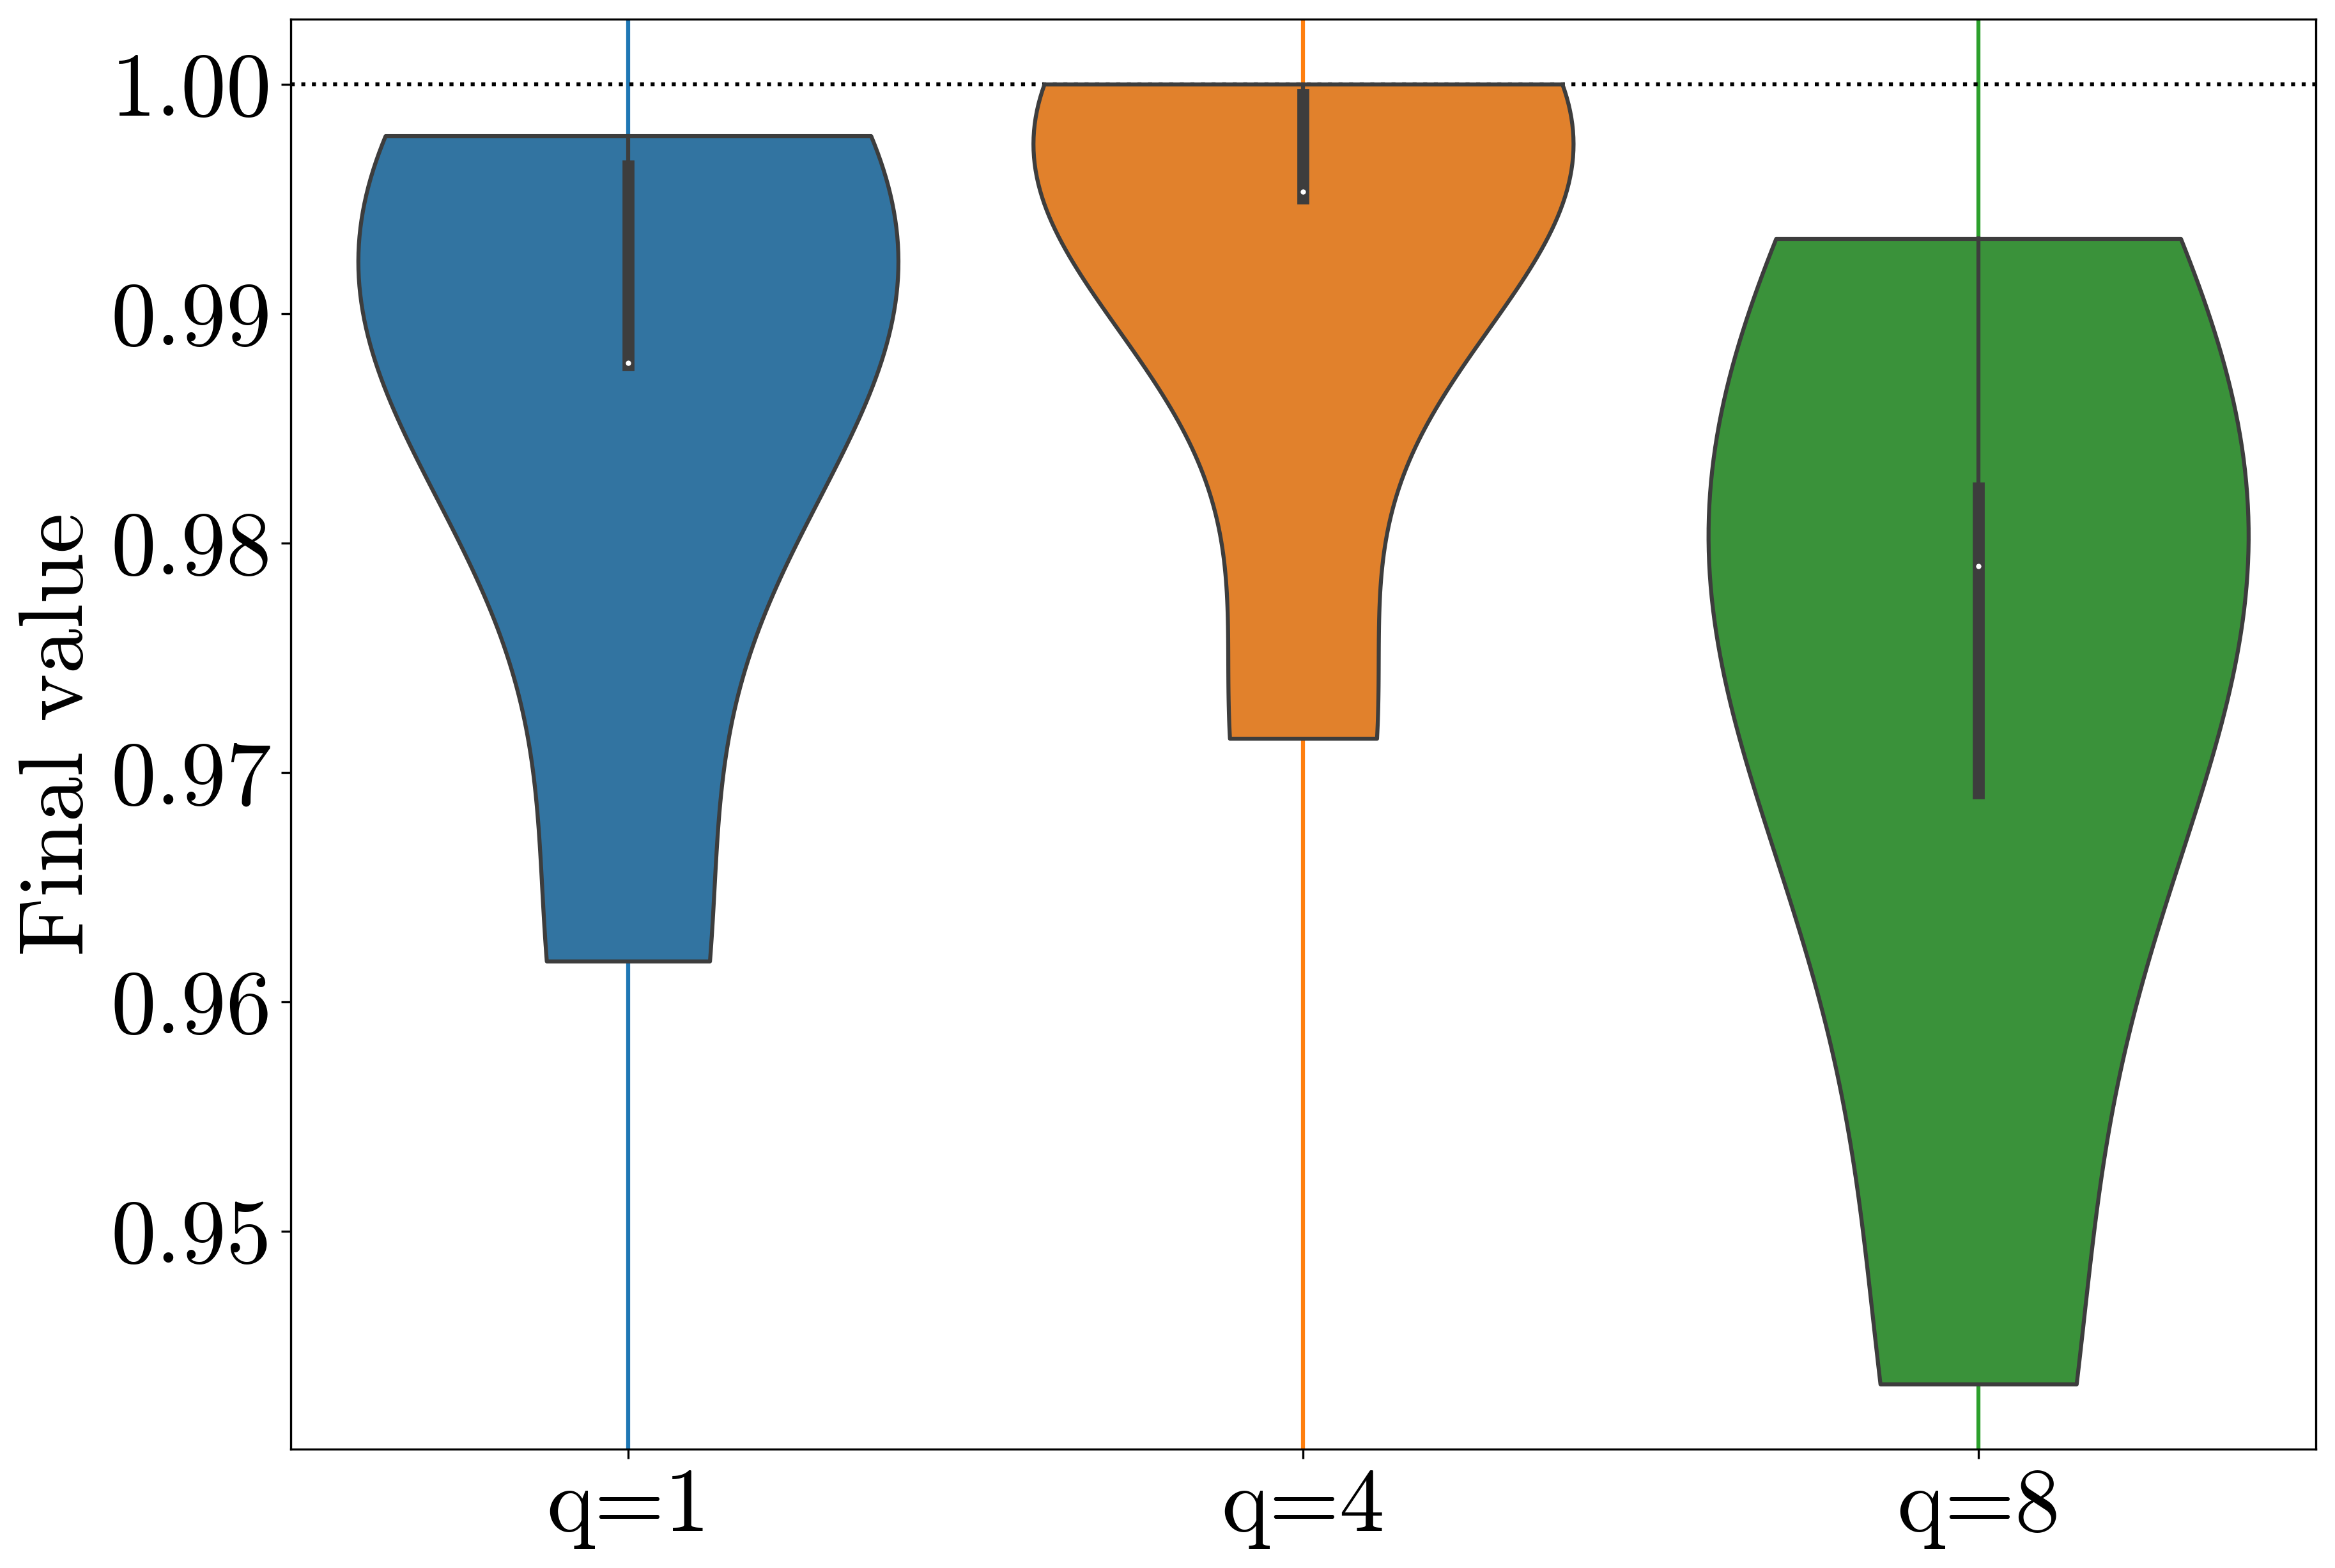

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
#sorted_results5 = Res_dict_raw['random']

df = pd.read_csv('../prop_data/MORDRED_SMILES_cep_PCE.csv')

end = -2
dmin = np.array(df['y1'].to_list()).min()#[df['activity']>=11.]
dmax = np.array(df['y1'].to_list()).max()#[df['activity']>=11.]

names2 = ['q=1','q=4',"q=8"]


df2 = pd.DataFrame()

sorted_results = Res_dict_raw[names[0]] 
d =  pd.DataFrame({'Method':[names2[0]]*len(seeds), 'Final value':(sorted_results[0,:,end]-dmin)/(dmax-dmin)})
df2 = pd.concat([df2, d])

sorted_results = Res_dict_raw[names[1]] 
d =  pd.DataFrame({'Method':[names2[1]]*len(seeds), 'Final value':(sorted_results[0,:,end]-dmin)/(dmax-dmin)})
df2 = pd.concat([df2, d])


sorted_results = Res_dict_raw[names[2]] 
d =  pd.DataFrame({'Method':[names2[2]]*len(seeds), 'Final value':(sorted_results[0,:,end]-dmin)/(dmax-dmin)})
df2 = pd.concat([df2, d])
'''
d =  pd.DataFrame({'Method':[names2[3]]*len(seeds), 'Final value':(sorted_results4[0,:,end]-dmin)/(dmax-dmin)})
df2 = pd.concat([df2, d])

d =  pd.DataFrame({'Method':[names2[4]]*len(seeds), 'Final value':(sorted_results5[0,:,end]-dmin)/(dmax-dmin)})
df2 = pd.concat([df2, d])
'''




C = [ sns.color_palette()[0], sns.color_palette()[1],
     sns.color_palette()[2], sns.color_palette()[3], sns.color_palette()[4],
     sns.color_palette()[5], sns.color_palette()[6], sns.color_palette()[6],
     sns.color_palette()[7], sns.color_palette()[8], sns.color_palette()[9],
 '#7f7f7f', '#bcbd22', '#17becf']
plt.figure(figsize=(13,9))
for i,ls in enumerate(range(3)):
  plt.axvline(i, color=C[i], linestyle='-', zorder=0)
plt.axhline(1,color='k', linestyle=':',zorder=0)
sns.violinplot(data=df2, x='Method', y='Final value', cut=0, inner="box", scale='width', palette=C, linestyle='dashdot')
#plt.title('Lipophilicity')
plt.xlabel(None)
#plt.ylim(.93,1.001)
#density_norm{“area”, “count”, “width”}
plt.tight_layout()
plt.savefig('./figs/cep/finalVals_q.png')





In [ ]:
df